In [19]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

Matplotlib is building the font cache; this may take a moment.


In [2]:
model_infile = '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_CanESM5-dcppA-hindcast_196101-201701_MJJ_nem-2030.nc'
obs_infile = '/g/data/xv83/unseen-projects/outputs/wind-drought/data/sfcWind_BARRA-R2_1979-2025_MJJ_nem-2030.nc'

In [3]:
ds_model = xr.open_dataset(model_infile)
ds_model = ds_model.compute()

In [11]:
ds_model

<xarray.Dataset> Size: 9MB
Dimensions:    (init_date: 57, ensemble: 20, lead_time: 920)
Coordinates:
  * ensemble   (ensemble) int64 160B 0 1 2 3 4 5 6 7 ... 12 13 14 15 16 17 18 19
  * lead_time  (lead_time) int64 7kB 0 1 2 3 4 5 6 ... 914 915 916 917 918 919
  * init_date  (init_date) object 456B 1961-05-01 00:00:00 ... 2017-05-01 00:...
    time       (lead_time, init_date) object 420kB 1961-05-01 12:00:00 ... 20...
Data variables:
    sfcWind    (init_date, ensemble, lead_time) float64 8MB 3.944 3.93 ... 4.78
Attributes: (12/53)
    CCCma_model_hash:            Unknown
    CCCma_parent_runid:          d2a-asm-e01
    CCCma_pycmor_hash:           13db8596c37129e414cad7ae31f2927ca8f5dd39
    CCCma_runid:                 d2a196101e01
    Conventions:                 CF-1.7 CMIP-6.2
    YMDH_branch_time_in_child:   1961:01:01:00
    ...                          ...
    tracking_id:                 hdl:21.14100/06d13276-8392-455a-90a3-8583122...
    variable_id:                 sfcWind
    variant_label:               r1i1p2f1
    version:                     v20190429
    license:                     CMIP6 model data produced by The Government ...
    cmor_version:                3.4.0

In [13]:
57 * 20 * 920

1048800

In [ ]:
ds_obs = xr.open_dataset(obs_infile)
ds_obs = ds_obs.compute()

In [8]:
ds_obs

In [15]:
sfcWind_model_data = ds_model['sfcWind'].stack({'sample': ['ensemble', 'init_date', 'lead_time']}).values

In [ ]:
sfcWind_obs_data = ds_obs['sfcWind'].values

In [23]:
pctl10 = np.percentile(sfcWind_model_data, 10)

In [24]:
print(pctl10)

3.536619275782543


In [34]:
bins = np.arange(0, 9.5, 0.5)

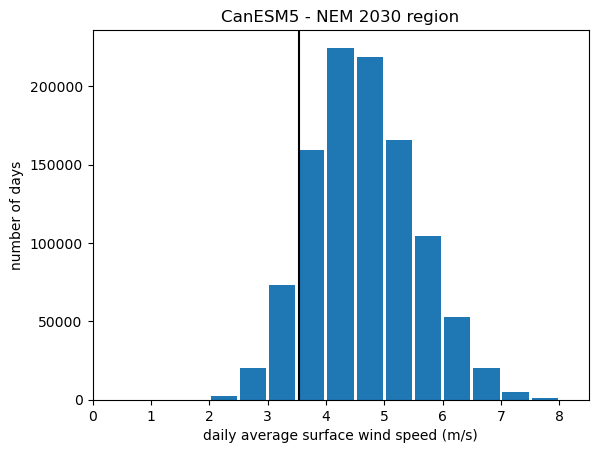

In [38]:
plt.hist(sfcWind_model_data, bins=bins, rwidth=0.9, label='CanESM5', alpha=0.5)
plt.hist(sfcWind_obs_data, bins=bins, rwidth=0.9, label='BARRA-R2', alpha=0.5)
plt.axvline(pctl10, color='black', label='10th percentile')
plt.xlabel('daily average surface wind speed (m/s)')
plt.ylabel('number of days')
plt.title('CanESM5 - NEM 2030 region')
plt.xlim(0, 8.5)
plt.legend()
plt.show()